# Week 2: Feature Engineering and Model Building

This notebook builds a complete Phase 2 machine learning workflow for churn prediction:

- Prepare and validate model-ready features
- Build preprocessing pipelines
- Train baseline models
- Tune a stronger model
- Evaluate and compare performance
- Save the best model for Week 3/4 use

In [23]:
# 1) Imports and configuration
import warnings
import sys
import json
from datetime import datetime, timezone
from pathlib import Path
import importlib

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    mean_squared_error,
    make_scorer,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Ensure local src/ modules are importable when running notebook from notebooks/
project_root_for_imports = Path.cwd().resolve()
candidate = project_root_for_imports
for _ in range(8):
    if (candidate / "src").exists():
        project_root_for_imports = candidate
        break
    if candidate.parent == candidate:
        break
    candidate = candidate.parent
if str(project_root_for_imports) not in sys.path:
    sys.path.insert(0, str(project_root_for_imports))

# Reload local module so notebook always uses latest src/preprocessing.py edits.
import src.preprocessing as preprocessing
importlib.reload(preprocessing)
infer_feature_columns = preprocessing.infer_feature_columns
build_preprocessor = preprocessing.build_preprocessor

# Optional dependency: include XGBoost in model comparison when available.
HAS_XGBOOST = importlib.util.find_spec("xgboost") is not None
if HAS_XGBOOST:
    XGBClassifier = importlib.import_module("xgboost").XGBClassifier
else:
    XGBClassifier = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### Step 2: Load Data and Define Target
We use the cleaned churn dataset from the data folder and convert `Churn` into a binary target.

In [24]:
# 2) Load dataset and set up target
project_root = Path.cwd().resolve()
 
# Find the project root by walking upward until data/cleaned_churn_data.csv exists
candidate = project_root
for _ in range(8):
    if (candidate / "data" / "cleaned_churn_data.csv").exists():
        project_root = candidate
        break
    if candidate.parent == candidate:
        break
    candidate = candidate.parent
 
data_path = project_root / "data" / "cleaned_churn_data.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find dataset at expected path: {data_path}")
 
df = pd.read_csv(data_path)
 
print(f"Using data file: {data_path}")
print(f"Dataset shape: {df.shape}")
display(df.head())
 
if "Churn" not in df.columns:
    raise ValueError("Expected target column 'Churn' not found in dataset.")
 
# Convert target to binary and support both string and numeric encodings.
churn_raw = df["Churn"]
if pd.api.types.is_numeric_dtype(churn_raw):
    y = pd.to_numeric(churn_raw, errors="coerce")
else:
    churn_norm = churn_raw.astype(str).str.strip().str.lower()
    y = churn_norm.map({"no": 0, "yes": 1, "0": 0, "1": 1, "false": 0, "true": 1})

if y.isna().any():
    invalid_values = sorted(df.loc[y.isna(), "Churn"].astype(str).unique().tolist())
    raise ValueError(
        "Target contains unexpected labels. Supported values: Yes/No or 1/0. "
        f"Found: {invalid_values[:10]}"
    )

y = y.astype(int)
X = df.drop(columns=["Churn"])
print("Target distribution (0=No churn, 1=Churn):")
print(y.value_counts(normalize=True).rename("proportion"))

Using data file: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/data/cleaned_churn_data.csv
Dataset shape: (7043, 32)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,14.925000,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,36.050000,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,40.016304,True,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,50.550000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


Target distribution (0=No churn, 1=Churn):
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


### Step 3: Train/Test Split and Preprocessing Pipeline
Categorical features are one-hot encoded and numerical features are imputed/scaled within a single reusable pipeline.

In [25]:
# 3) Train/test split and preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols, categorical_cols = infer_feature_columns(X_train)

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

preprocessor = build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
)

Numeric features (9): ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']
Categorical features (22): ['gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### Step 4: Baseline Model Training
We train three baseline models using the same preprocessing logic and compare classification metrics.

In [26]:
# 4) Baseline models
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}
 
if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
    )
else:
    print("XGBoost not installed. Skipping XGBoost baseline model.")
 
baseline_results = []
fitted_pipelines = {}
 
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
 
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
 
    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    }
 
    baseline_results.append(result)
    fitted_pipelines[name] = pipe
 
baseline_df = pd.DataFrame(baseline_results).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(baseline_df.style.format({col: "{:.4f}" for col in baseline_df.columns if col != "model"}))

XGBoost not installed. Skipping XGBoost baseline model.


,model,accuracy,precision,recall,f1,rmse,roc_auc
0,LogisticRegression,0.8105,0.6814,0.5374,0.6009,0.4353,0.8464
1,GradientBoosting,0.7949,0.6481,0.4973,0.5628,0.4529,0.8440
2,RandomForest,0.7786,0.6013,0.4920,0.5412,0.4706,0.8210


### Step 5: Hyperparameter Tuning (Random Forest)
We tune Random Forest using cross-validated F1 score to improve churn-class prediction quality.

In [27]:
# 5) Hyperparameter tuning for Random Forest
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
    ]
)
 
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 14],
    "model__min_samples_split": [2, 8],
    "model__min_samples_leaf": [1, 3],
}
 
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring=make_scorer(f1_score),
    cv=5,
    n_jobs=-1,
    verbose=0,
    refit=True,
 )
 
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best RF params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

Best RF params: {'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__min_samples_split': 8, 'model__n_estimators': 400}
Best CV F1: 0.6380


### Step 6: Final Evaluation and Visual Diagnostics
We compare the tuned model against baselines and inspect confusion matrix plus ROC curve.

,model,accuracy,precision,recall,f1,rmse,roc_auc
0,TunedRandomForest,0.7608,0.5336,0.7861,0.6357,0.4891,0.8434
1,LogisticRegression,0.8105,0.6814,0.5374,0.6009,0.4353,0.8464
2,GradientBoosting,0.7949,0.6481,0.4973,0.5628,0.4529,0.8440
3,RandomForest,0.7786,0.6013,0.4920,0.5412,0.4706,0.8210


Selected final model: TunedRandomForest

Classification report (final model):
              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



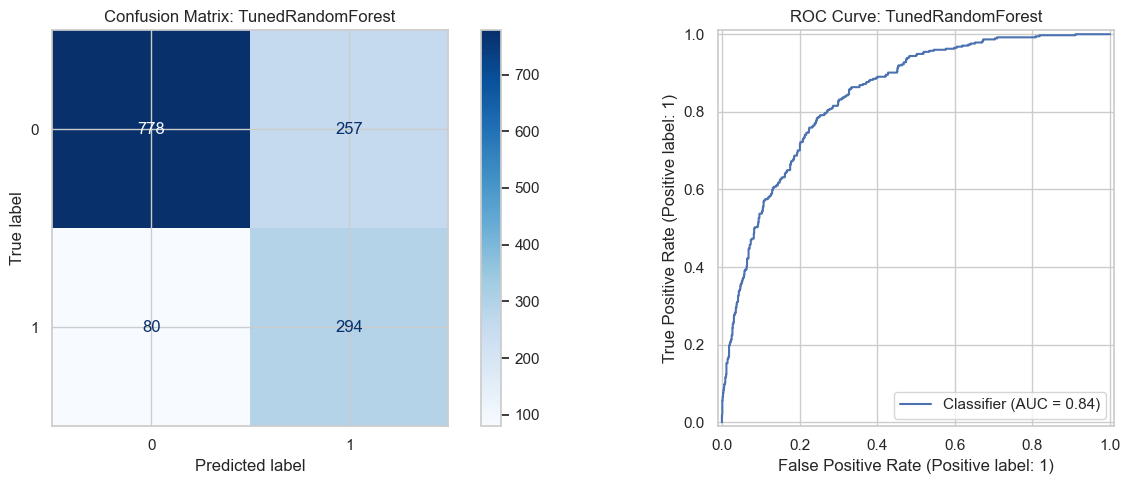

In [28]:
# 6) Final evaluation
best_name = baseline_df.loc[0, "model"]
best_baseline_pipe = fitted_pipelines[best_name]
 
# Evaluate tuned model
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
 
tuned_metrics = {
    "model": "TunedRandomForest",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "rmse": mean_squared_error(y_test, y_pred_tuned) ** 0.5,
    "roc_auc": roc_auc_score(y_test, y_prob_tuned),
}
 
comparison_df = pd.concat([baseline_df, pd.DataFrame([tuned_metrics])], ignore_index=True)
comparison_df = comparison_df.sort_values(by="f1", ascending=False).reset_index(drop=True)
display(comparison_df.style.format({col: "{:.4f}" for col in comparison_df.columns if col != "model"}))
 
final_model_name = comparison_df.loc[0, "model"]
if final_model_name == "TunedRandomForest":
    final_model = best_model
else:
    final_model = best_baseline_pipe
 
print(f"Selected final model: {final_model_name}")
print("\nClassification report (final model):")
y_pred_final = final_model.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=["No Churn", "Churn"]))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion Matrix: {final_model_name}")
 
y_prob_final = final_model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_final, ax=axes[1])
axes[1].set_title(f"ROC Curve: {final_model_name}")
plt.tight_layout()
plt.show() 

In [21]:
# 7) Threshold optimization using ML and business criteria
OFFER_COST = 15.0
CUSTOMER_VALUE = 180.0
RETENTION_SUCCESS_RATE = 0.30

threshold_grid = np.linspace(0.05, 0.95, 91)
threshold_records = []

for t in threshold_grid:
    y_pred_t = (y_prob_final >= t).astype(int)
    targeted = int(y_pred_t.sum())
    tp = int(((y_pred_t == 1) & (y_test.values == 1)).sum())

    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)
    precision_t = precision_score(y_test, y_pred_t, zero_division=0)

    # Evaluation-time business proxy: expected net value of targeting predicted churners
    expected_retained = tp * RETENTION_SUCCESS_RATE
    expected_profit = (expected_retained * CUSTOMER_VALUE) - (targeted * OFFER_COST)

    threshold_records.append(
        {
            "threshold": float(t),
            "f1": float(f1_t),
            "recall": float(recall_t),
            "precision": float(precision_t),
            "targeted_customers": targeted,
            "true_positives": tp,
            "expected_profit": float(expected_profit),
        }
    )

threshold_df = pd.DataFrame(threshold_records)
profit_min = threshold_df["expected_profit"].min()
profit_max = threshold_df["expected_profit"].max()
if profit_max > profit_min:
    threshold_df["profit_norm"] = (threshold_df["expected_profit"] - profit_min) / (profit_max - profit_min)
else:
    threshold_df["profit_norm"] = 0.0

# Composite score balances predictive quality and business value
F1_WEIGHT = 0.55
RECALL_WEIGHT = 0.25
PROFIT_WEIGHT = 0.20
threshold_df["composite_score"] = (
    F1_WEIGHT * threshold_df["f1"]
    + RECALL_WEIGHT * threshold_df["recall"]
    + PROFIT_WEIGHT * threshold_df["profit_norm"]
)

best_threshold_row = threshold_df.sort_values("composite_score", ascending=False).iloc[0]
OPTIMAL_THRESHOLD = float(best_threshold_row["threshold"])

print(f"Optimal threshold selected: {OPTIMAL_THRESHOLD:.2f}")
display(
    threshold_df.sort_values("composite_score", ascending=False).head(10).reset_index(drop=True)
    .style.format({"threshold": "{:.2f}", "f1": "{:.4f}", "recall": "{:.4f}", "precision": "{:.4f}", "expected_profit": "${:,.2f}", "composite_score": "{:.4f}"})
)

df_results = pd.DataFrame()
df_results["churn_probability"] = y_prob_final
df_results["risk_level"] = np.where(df_results["churn_probability"] >= OPTIMAL_THRESHOLD, "High Risk", "Low Risk")
df_results["threshold_used"] = OPTIMAL_THRESHOLD

display(df_results.head(10))

Optimal threshold selected: 0.39


,threshold,f1,recall,precision,targeted_customers,true_positives,expected_profit,profit_norm,composite_score
0,0.39,0.6179,0.8583,0.4827,665,321,"$7,359.00",0.966890,0.7478
1,0.50,0.6357,0.7861,0.5336,551,294,"$7,611.00",1.000000,0.7461
2,0.49,0.6332,0.7914,0.5276,561,296,"$7,569.00",0.994482,0.7450
3,0.41,0.6181,0.8396,0.4891,642,314,"$7,326.00",0.962554,0.7424
4,0.42,0.6195,0.8316,0.4937,630,311,"$7,344.00",0.964919,0.7416
5,0.46,0.6264,0.8048,0.5128,587,301,"$7,449.00",0.978715,0.7415
6,0.40,0.6160,0.8449,0.4847,652,316,"$7,284.00",0.957036,0.7414
7,0.48,0.6292,0.7941,0.5211,570,297,"$7,488.00",0.983839,0.7414
8,0.38,0.6106,0.8636,0.4722,684,323,"$7,182.00",0.943634,0.7405
9,0.45,0.6241,0.8102,0.5075,597,303,"$7,407.00",0.973197,0.7404


,churn_probability,risk_level,threshold_used
0,0.045710,Low Risk,0.39
1,0.828622,High Risk,0.39
2,0.163336,Low Risk,0.39
3,0.640053,High Risk,0.39
4,0.047554,Low Risk,0.39
5,0.701372,High Risk,0.39
6,0.599568,High Risk,0.39
7,0.183781,Low Risk,0.39
8,0.022019,Low Risk,0.39
9,0.620692,High Risk,0.39


### Step 8: Save Best Model, Metrics, and Model Metadata
Persist trained artifacts for downstream analysis and track model version/threshold metadata.

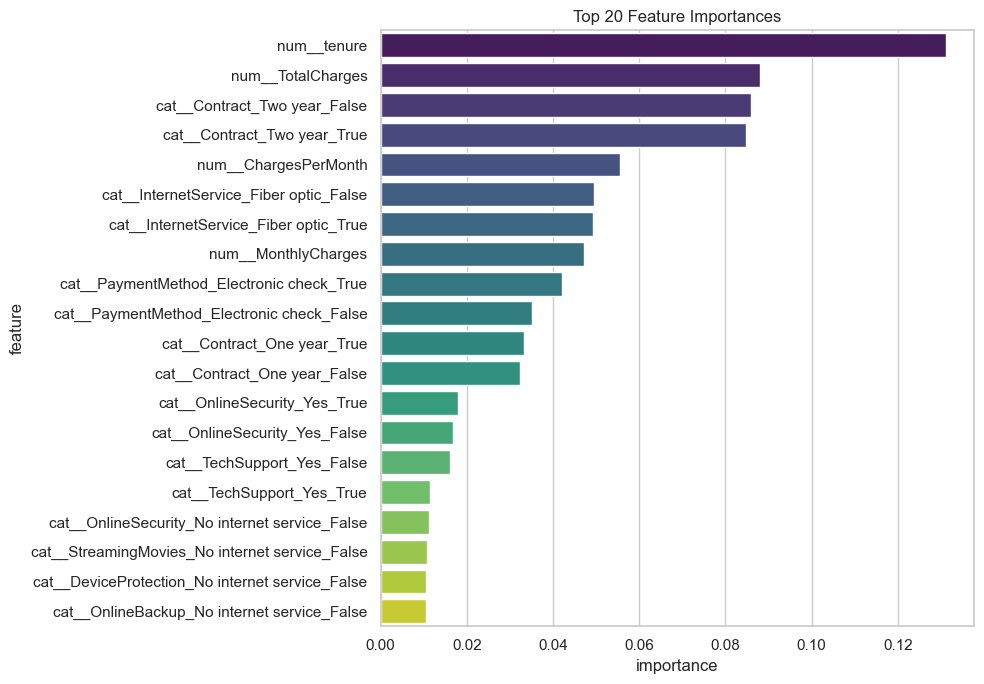

Saved feature importance chart: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/figures/week2_top_feature_importances.png
Saved best model: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/models/week2_best_model.joblib
Saved model comparison: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/reports/week2_model_comparison.csv
Saved model metadata: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/models/model_info.json


In [29]:
# 8) Save model, evaluation outputs, and model metadata
models_dir = project_root / "models"
reports_dir = project_root / "reports"
figures_dir = reports_dir / "figures"

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "week2_best_model.joblib"
metrics_path = reports_dir / "week2_model_comparison.csv"
model_info_path = models_dir / "model_info.json"

joblib.dump(final_model, model_path)
comparison_df.to_csv(metrics_path, index=False)

# Save feature importance if available
if hasattr(final_model.named_steps["model"], "feature_importances_"):
    feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
    importances = final_model.named_steps["model"].feature_importances_
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi, x="importance", y="feature", hue="feature", dodge=False, palette="viridis", legend=False)
    plt.title("Top 20 Feature Importances")
    plt.tight_layout()
    fi_plot_path = figures_dir / "week2_top_feature_importances.png"
    plt.savefig(fi_plot_path, dpi=140)
    plt.show()
    print(f"Saved feature importance chart: {fi_plot_path}")

final_metrics_row = comparison_df.loc[comparison_df["model"] == final_model_name].iloc[0]
metrics_test = {
    "accuracy": float(final_metrics_row["accuracy"]),
    "precision": float(final_metrics_row["precision"]),
    "recall": float(final_metrics_row["recall"]),
    "f1": float(final_metrics_row["f1"]),
    "rmse": float(final_metrics_row["rmse"]),
    "roc_auc": float(final_metrics_row["roc_auc"]),
}

model_info = {
    "model_version": datetime.now(timezone.utc).strftime("v%Y%m%dT%H%M%SZ"),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_artifact": model_path.name,
    "model_type": final_model_name,
    "target_column": "Churn",
    "features_used": X_train.columns.tolist(),
    "preprocessing": {
        "numeric_features": numeric_cols,
        "categorical_features": categorical_cols,
    },
    "metrics_test": metrics_test,
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "threshold_selection": {
        "method": "composite_f1_recall_profit",
        "weights": {
            "f1": float(F1_WEIGHT),
            "recall": float(RECALL_WEIGHT),
            "profit": float(PROFIT_WEIGHT),
        },
        "quantile_basis": {
            "risk_threshold_quantile": 0.75,
            "uplift_low_quantile": 0.25,
            "uplift_high_quantile": 0.75,
        },
        "assumptions_business": {
            "offer_cost": float(OFFER_COST),
            "customer_value": float(CUSTOMER_VALUE),
            "retention_success_rate": float(RETENTION_SUCCESS_RATE),
        },
    },
}

with open(model_info_path, "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print(f"Saved best model: {model_path}")
print(f"Saved model comparison: {metrics_path}")
print(f"Saved model metadata: {model_info_path}")